# 🔄 Notebook 2: Redes Neuronales Recurrentes — LSTM
## Caso de Uso: Predicción de Series de Tiempo (Temperatura + Clasificación de Sentimientos)

En este notebook implementamos dos aplicaciones de LSTM:

1. **Parte A**: Predicción de temperatura (serie de tiempo multivariada)
2. **Parte B**: Clasificación de reseñas de películas (IMDb) con Embedding + LSTM

### ¿Por qué LSTM?
Las LSTM (Long Short-Term Memory) son una variante de las RNN que resuelven el problema del **gradiente desvaneciente**, permitiendo aprender dependencias a largo plazo en secuencias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.20.0


---
# PARTE A: Predicción de Serie de Tiempo — Temperatura
## 1. Generación del Dataset Sintético de Temperatura

       temperatura   tendencia    estacional
count  1460.000000  1460.00000  1.460000e+03
mean     20.258474    20.18850  1.557354e-16
std       8.522866     1.26483  8.488189e+00
min       2.688799    18.00000 -1.199989e+01
25%      12.534515    19.09425 -8.467003e+00
50%      20.131268    20.18850  3.859494e-15
75%      28.164154    21.28275  8.467003e+00
max      37.011501    22.37700  1.199989e+01


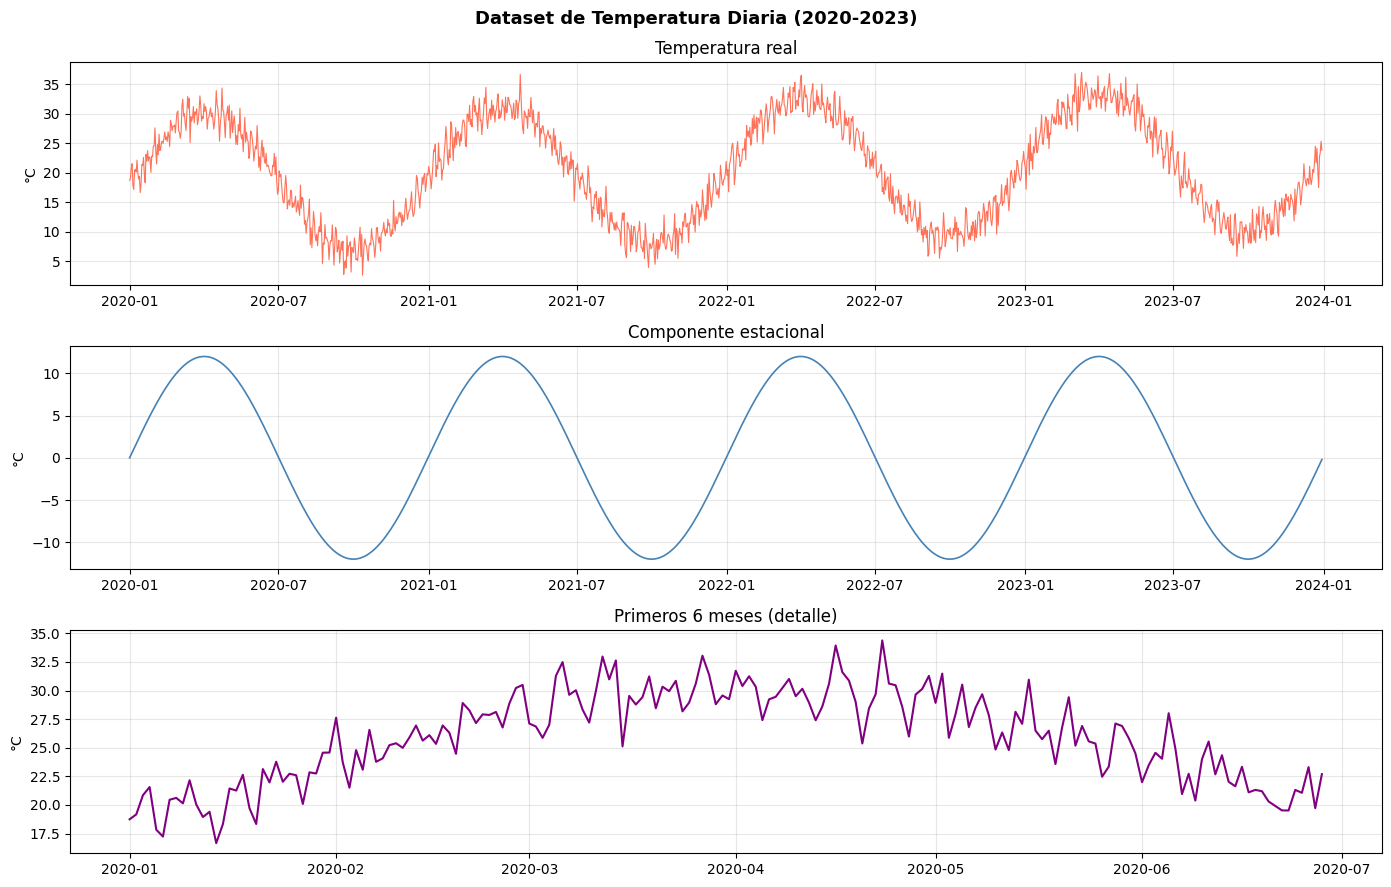

In [2]:
# Generamos un dataset de temperatura sintético realista
np.random.seed(42)
n_days = 1460  # 4 años de datos diarios

time   = np.arange(n_days)
trend  = 0.003 * time                            # tendencia de calentamiento leve
season = 12 * np.sin(2 * np.pi * time / 365)    # componente estacional anual
weekly = 1.5 * np.sin(2 * np.pi * time / 7)     # componente semanal
noise  = np.random.normal(0, 1.5, n_days)        # ruido gaussiano

temperature = 18 + trend + season + weekly + noise

# Crear DataFrame
dates = pd.date_range(start='2020-01-01', periods=n_days, freq='D')
df = pd.DataFrame({
    'fecha':       dates,
    'temperatura': temperature,
    'tendencia':   trend + 18,
    'estacional':  season
})
df.set_index('fecha', inplace=True)

print(df.describe())

# Visualización
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle('Dataset de Temperatura Diaria (2020-2023)', fontsize=13, fontweight='bold')

axes[0].plot(df.index, df['temperatura'], color='tomato', linewidth=0.8, alpha=0.9)
axes[0].set_title('Temperatura real')
axes[0].set_ylabel('°C')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['estacional'], color='steelblue', linewidth=1.2)
axes[1].set_title('Componente estacional')
axes[1].set_ylabel('°C')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index[:180], df['temperatura'][:180], color='purple', linewidth=1.5)
axes[2].set_title('Primeros 6 meses (detalle)')
axes[2].set_ylabel('°C')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_temperature_series.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Preparación de Secuencias para LSTM

In [3]:
# Normalización
scaler = MinMaxScaler(feature_range=(0, 1))
temp_scaled = scaler.fit_transform(df[['temperatura']].values)

def create_sequences(data, window_size=30):
    """Crea pares (secuencia de entrada, valor objetivo) para LSTM."""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30  # usamos 30 días para predecir el siguiente
X_seq, y_seq = create_sequences(temp_scaled, WINDOW_SIZE)

# División train / test (80 / 20)
split = int(len(X_seq) * 0.80)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f'Train: X={X_train.shape}, y={y_train.shape}')
print(f'Test:  X={X_test.shape},  y={y_test.shape}')

Train: X=(1144, 30, 1), y=(1144, 1)
Test:  X=(286, 30, 1),  y=(286, 1)


## 3. Construcción del Modelo LSTM

In [4]:
def build_lstm(window_size=30, n_features=1):
    """
    Modelo LSTM apilado con Dropout para predicción de series de tiempo.
    Arquitectura: LSTM(128) -> Dropout -> LSTM(64) -> Dropout -> Dense(1)
    """
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=(window_size, n_features),
                    recurrent_dropout=0.1),
        layers.Dropout(0.2),
        layers.LSTM(64, return_sequences=False, recurrent_dropout=0.1),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)   # regresión: salida continua
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_model = build_lstm(window_size=WINDOW_SIZE)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Entrenamiento
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)
print('\n✅ Entrenamiento LSTM completado!')

Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - loss: 0.0415 - mae: 0.1443 - val_loss: 0.0118 - val_mae: 0.0890
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0081 - mae: 0.0709 - val_loss: 0.0069 - val_mae: 0.0685
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.0072 - mae: 0.0666 - val_loss: 0.0059 - val_mae: 0.0624
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - loss: 0.0070 - mae: 0.0654 - val_loss: 0.0054 - val_mae: 0.0596
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0064 - mae: 0.0630 - val_loss: 0.0066 - val_mae: 0.0667
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0061 - mae: 0.0624 - val_loss: 0.0045 - val_mae: 0.0538
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0058 - mae: 0.0594 - val_loss: 0.0064 - val_mae: 0.0649
Epoch 8/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 0.0064 - mae: 0.0627 - val_loss: 0.0067 - val_mae: 0.0668
Epoch 9/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0

=== Métricas de Evaluación LSTM ===
RMSE : 2.036 °C
MAE  : 1.639 °C
R²   : 0.9415


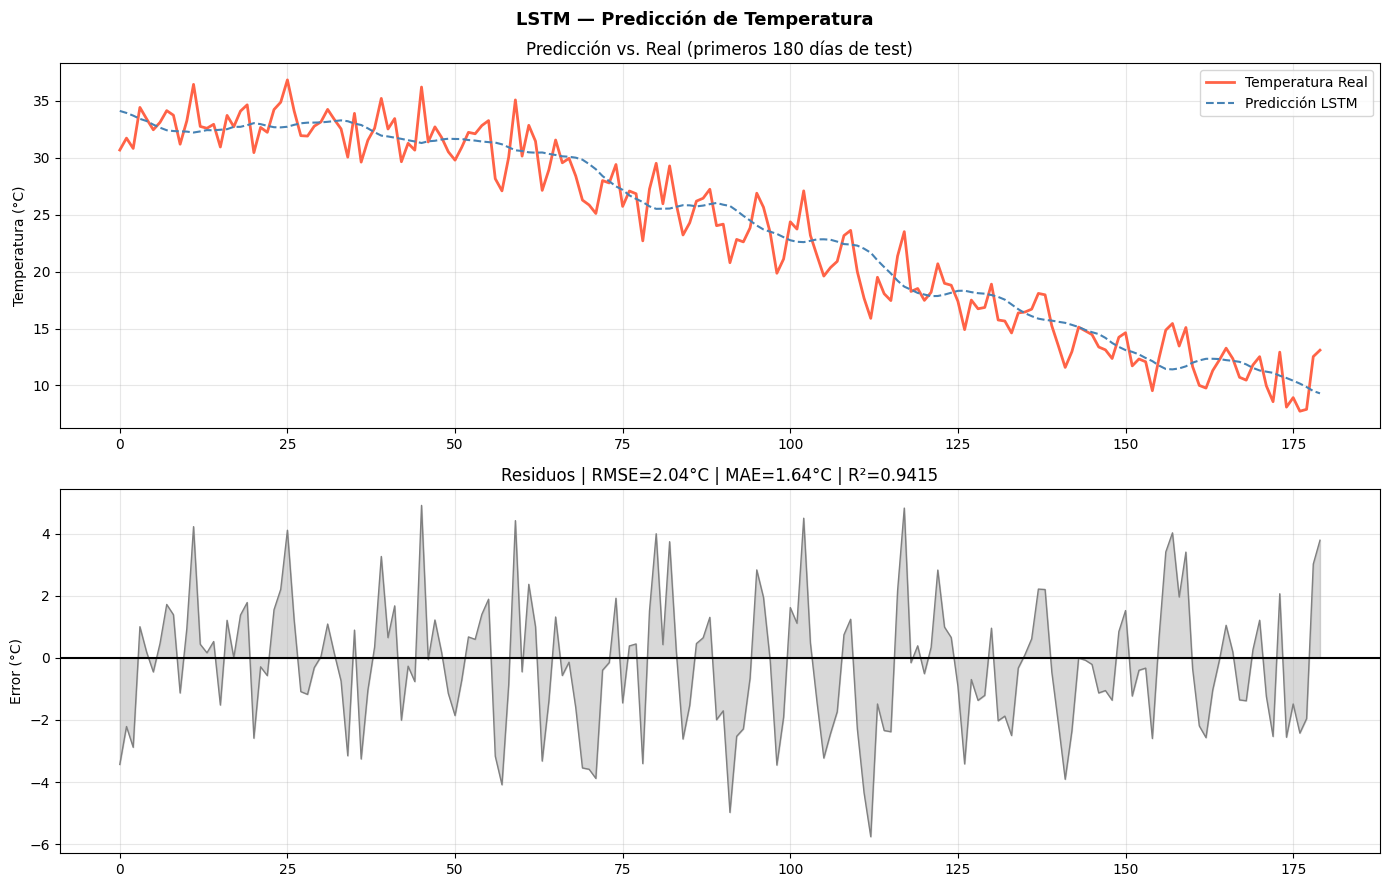

In [6]:
# Predicciones y desnormalización
y_pred_scaled = lstm_model.predict(X_test, verbose=0)
y_pred        = scaler.inverse_transform(y_pred_scaled)
y_real        = scaler.inverse_transform(y_test)

# Métricas
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae  = mean_absolute_error(y_real, y_pred)
r2   = r2_score(y_real, y_pred)

print('=== Métricas de Evaluación LSTM ===')
print(f'RMSE : {rmse:.3f} °C')
print(f'MAE  : {mae:.3f} °C')
print(f'R²   : {r2:.4f}')

# Visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('LSTM — Predicción de Temperatura', fontsize=13, fontweight='bold')

ax1.plot(y_real[:180],  label='Temperatura Real', color='tomato',    linewidth=2)
ax1.plot(y_pred[:180],  label='Predicción LSTM',  color='steelblue', linewidth=1.5, linestyle='--')
ax1.set_title('Predicción vs. Real (primeros 180 días de test)')
ax1.set_ylabel('Temperatura (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)

residuals = y_real - y_pred
ax2.plot(residuals[:180], color='gray', linewidth=1)
ax2.axhline(0, color='black', linewidth=1.5)
ax2.fill_between(range(180), residuals[:180, 0], alpha=0.3, color='gray')
ax2.set_title(f'Residuos | RMSE={rmse:.2f}°C | MAE={mae:.2f}°C | R²={r2:.4f}')
ax2.set_ylabel('Error (°C)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_temperature_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE B: Clasificación de Texto con Embedding + LSTM
## Caso: Clasificación de Reseñas de Películas (IMDb)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Reseñas de entrenamiento: 25000
Reseñas de prueba:        25000
Etiquetas únicas:         [0 1] (0=neg, 1=pos)

Shape train: (25000, 200)
Shape test:  (25000, 200)


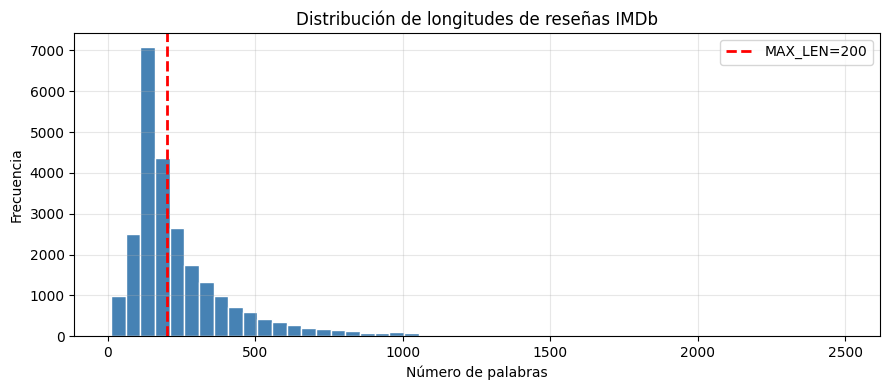

In [7]:
# Cargar dataset IMDb (50,000 reseñas de películas)
VOCAB_SIZE  = 10000
MAX_LEN     = 200

(X_train_imdb, y_train_imdb), (X_test_imdb, y_test_imdb) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print(f'Reseñas de entrenamiento: {len(X_train_imdb)}')
print(f'Reseñas de prueba:        {len(X_test_imdb)}')
print(f'Etiquetas únicas:         {np.unique(y_train_imdb)} (0=neg, 1=pos)')

# Padding / Truncating para longitud uniforme
X_train_pad = pad_sequences(X_train_imdb, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_imdb,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nShape train: {X_train_pad.shape}')
print(f'Shape test:  {X_test_pad.shape}')

# Distribución de longitudes de reseñas
lengths = [len(x) for x in X_train_imdb]
plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
plt.title('Distribución de longitudes de reseñas IMDb')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_imdb_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Modelo: Embedding + LSTM para clasificación binaria
def build_lstm_text(vocab_size=10000, max_len=200, embed_dim=64):
    """
    Arquitectura para NLP:
    - Embedding layer: convierte índices de palabras en vectores densos
    - LSTM bidireccional para capturar contexto en ambas direcciones
    - Clasificación binaria (positivo/negativo)
    """
    model = models.Sequential([
        layers.Embedding(vocab_size, embed_dim, input_length=max_len),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')  # clasificación binaria
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_text_model = build_lstm_text(VOCAB_SIZE, MAX_LEN)
lstm_text_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.7225 - loss: 0.5367 - val_accuracy: 0.8224 - val_loss: 0.4034
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8626 - loss: 0.3376 - val_accuracy: 0.8204 - val_loss: 0.4011
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9067 - loss: 0.2516 - val_accuracy: 0.8532 - val_loss: 0.3676
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.9224 - loss: 0.2178 - val_accuracy: 0.8556 - val_loss: 0.4021
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9306 - loss: 0.1963 - val_accuracy: 0.8496 - val_loss: 0.4553
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9373 - loss: 0.1709 - val_accuracy: 0.8548 - val_loss: 0.5425
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9493 - loss: 0.1439 - val_accuracy: 0.8466 - val_loss: 0.5688

=== Evaluación en Test ===
Accuracy: 0.8388 (83.88%)
Loss:     0.4462


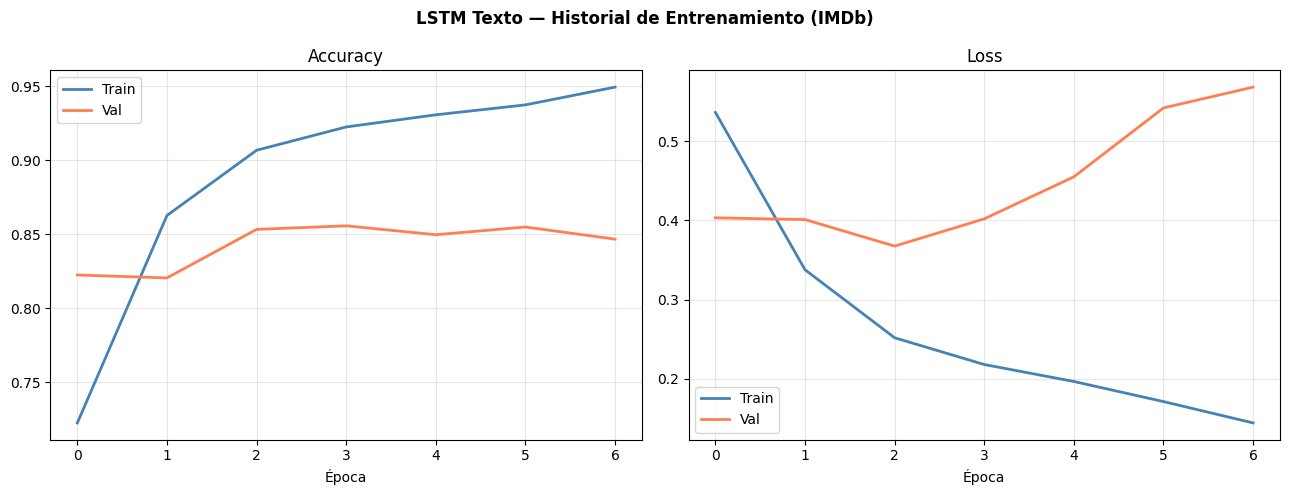

In [9]:
# Entrenamiento del modelo de clasificación de texto
cb_text = [EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]

history_text = lstm_text_model.fit(
    X_train_pad, y_train_imdb,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=cb_text,
    verbose=1
)

# Evaluación
loss, acc = lstm_text_model.evaluate(X_test_pad, y_test_imdb, verbose=0)
print(f'\n=== Evaluación en Test ===')
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print(f'Loss:     {loss:.4f}')

# Gráfico de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LSTM Texto — Historial de Entrenamiento (IMDb)', fontsize=12, fontweight='bold')

ax1.plot(history_text.history['accuracy'],     label='Train', color='steelblue', linewidth=2)
ax1.plot(history_text.history['val_accuracy'], label='Val',   color='coral',     linewidth=2)
ax1.set_title('Accuracy'); ax1.set_xlabel('Época'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_text.history['loss'],     label='Train', color='steelblue', linewidth=2)
ax2.plot(history_text.history['val_loss'], label='Val',   color='coral',     linewidth=2)
ax2.set_title('Loss'); ax2.set_xlabel('Época'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_text_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Predicciones en ejemplos específicos
word_index = imdb.get_word_index()
idx_to_word = {v+3: k for k, v in word_index.items()}
idx_to_word.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

# Mostrar 6 ejemplos con predicciones
print('=== Predicciones en Reseñas de Test ===\n')
sample_indices = [0, 1, 2, 100, 101, 102]

for idx in sample_indices:
    # Reconstruir texto
    review_text = ' '.join([idx_to_word.get(i, '?') for i in X_test_imdb[idx][:50]])
    prob      = lstm_text_model.predict(X_test_pad[idx:idx+1], verbose=0)[0][0]
    pred_label = 'POSITIVO ✅' if prob >= 0.5 else 'NEGATIVO ❌'
    real_label = 'POSITIVO ✅' if y_test_imdb[idx] == 1 else 'NEGATIVO ❌'

    print(f'Reseña #{idx}: "{review_text[:100]}..."')
    print(f'  Real: {real_label} | Predicción: {pred_label} (prob={prob:.3f})')
    print()

print('✅ Notebook LSTM completado!')

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Predicciones en Reseñas de Test ===

Reseña #0: "<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible per..."
  Real: NEGATIVO ❌ | Predicción: NEGATIVO ❌ (prob=0.013)

Reseña #1: "<START> this film requires a lot of patience because it focuses on mood and character development th..."
  Real: POSITIVO ✅ | Predicción: POSITIVO ✅ (prob=0.981)

Reseña #2: "<START> many animation buffs consider <UNK> <UNK> the great forgotten genius of one special branch o..."
  Real: POSITIVO ✅ | Predicción: POSITIVO ✅ (prob=0.968)

Reseña #100: "<START> a quick glance at the premise of this film would seem to indicate just another dumb <UNK> <U..."
  Real: POSITIVO ✅ | Predicción: NEGATIVO ❌ (prob=0.014)

Reseña #101: "<START> <UNK> is the first of its kind in turkish cinema and it's way better than i expected those p..."
  Real: POSITIVO ✅ | Predicción: NEGATIVO ❌ (prob=0.037)

Reseña #102: "<START> this is a